# KMRF Model - Single Asset Test Notebook

This notebook demonstrates the KMRF (KAMA+MSR+RF) regime prediction pipeline for a single asset:

1. Initialize KMRF model for a specific asset
2. Load pre-computed features and KAMA+MSR labels
3. Adapt 4-regime labels to 3-class KMRF labels
4. Load and combine macroeconomic features
5. Split data into train/validation/test sets
6. (Optional) Feature selection with Boruta
7. Visualize regimes and data

In [12]:
# %pip install -r requirements.txt

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import kmrf as kmrf

%matplotlib inline

## 1. Initialize KMRF Model for Specific Asset

In [14]:
# Define asset to analyze
asset_name = 'SPDR S&P 500 ETF'  # SPY
asset_class = 'us_equity'
# asset_name = 'Gold Futures'
# asset_class = 'commodity'

# Initialize KMRF for this specific asset
kmrf_model = kmrf.KMRF(
    asset_name=asset_name,
    asset_class=asset_class,
    end_date='20190101',
    use_ready_data=True,
    validation_start='2019-04-01',
    validation_end='2019-09-30',
    test_start='2020-01-01',
    random_seed=1010
)

print(f"\n{kmrf_model}")

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-04-01 to 2019-09-30
  Test start: 2020-01-01
  Random seed: 1010

KMRF('SPDR S&P 500 ETF', us_equity)


## 2. Load Data and Features

In [15]:
# Load data for this asset
data = kmrf_model.load_data()

# Extract pre-computed features
features = kmrf_model.get_features()

print(f"\nData shape: {data.shape}")
print(f"Features shape: {features.shape}")
print(f"Date range: {features.index[0]} to {features.index[-1]}")


Loading data from: data/ready/us_equity.csv
Loaded data for: SPDR S&P 500 ETF
  Rows: 9022
  Columns: 112
  Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00

Extracting pre-computed features for SPDR S&P 500 ETF...
  Features shape: (9022, 112)

Data shape: (9022, 112)
Features shape: (9022, 112)
Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00


## 3. Load KAMA+MSR Labels

In [16]:
# Load original 4-regime labels from saved models
original_labels = kmrf_model.load_kama_msr_labels()


LOADING KAMA+MSR LABELS FOR SPDR S&P 500 ETF
Model directory: saved_models/KAMA_MSR/us_equity/20190101
Loading from: SPDR S&P 500 ETF_KAMA-MSR_4-regimes.pkl
✓ Loaded labels for: SPDR S&P 500 ETF
  Label date range: 1995-01-04 00:00:00 to 2018-12-31 00:00:00
  Total periods: 6041

  Original 4-regime distribution:
    0 -   LV Bullish:  4560 ( 75.7%)
    1 -   LV Bearish:  1138 ( 18.9%)
    2 -   HV Bullish:    26 (  0.4%)
    3 -   HV Bearish:   299 (  5.0%)


## 4. Adapt Labels (4-regime → 3-class)

In [17]:
# Adapt to 3-class KMRF labels
adapted_labels = kmrf_model.adapt_regime_labels()


ADAPTING REGIME LABELS FOR SPDR S&P 500 ETF

  Adapted 3-class distribution:
     Bullish ( 1):  4908 ( 81.2%)
       Other ( 0):   312 (  5.2%)
     Bearish (-1):   821 ( 13.6%)


## 5. Visualize Adapted Labels on Price Chart

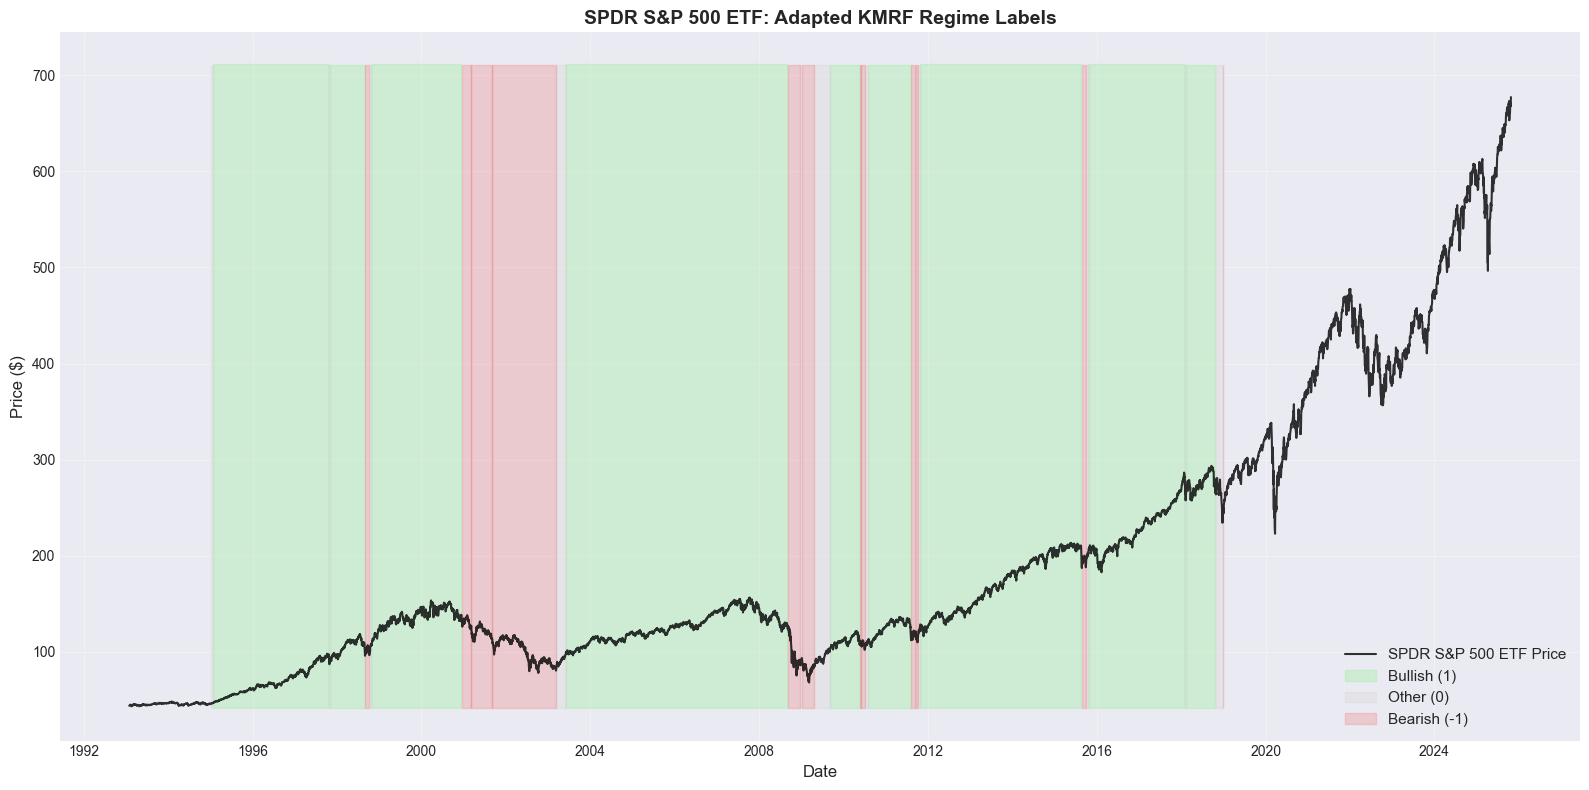

✓ Visualization complete!


In [18]:
# Get close price
close_cols = [col for col in features.columns if 'close' in col.lower() and 'sma' not in col.lower()]
close_price = features[close_cols[0]] if close_cols else None

if close_price is not None:
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Plot price
    ax.plot(close_price.index, close_price, color='black', linewidth=1.5, 
            alpha=0.8, label=f'{asset_name} Price', zorder=3)
    
    # Define colors
    colors = {1: 'lightgreen', 0: 'lightgray', -1: 'lightcoral'}
    labels_dict = {1: 'Bullish', 0: 'Other', -1: 'Bearish'}
    
    # Shade regions
    for regime in [1, 0, -1]:
        mask = adapted_labels == regime
        if mask.any():
            ax.fill_between(
                close_price.index,
                close_price.min() * 0.95,
                close_price.max() * 1.05,
                where=mask.reindex(close_price.index, fill_value=False),
                alpha=0.3,
                color=colors[regime],
                label=f'{labels_dict[regime]} ({regime})',
                zorder=1
            )
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price ($)', fontsize=12)
    ax.set_title(f'{asset_name}: Adapted KMRF Regime Labels', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3, zorder=2)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Visualization complete!")
else:
    print("Price data not available")

## 6. Prepare Training Data with Train/Val/Test Split

**New Feature:** Data is automatically split into:
- **Training**: All data before 2019-04-01
- **Validation**: 2019-04-01 to 2019-09-30
- **Test**: 2020-01-01 onwards

Set `select_features=True` to use Boruta feature selection (applied only on training data)

In [19]:
# Prepare training data with automatic splitting
# Set select_features=True to use Boruta (may take time)
X_train, y_train = kmrf_model.prepare_training_data(
    transform_labels=True,
    include_macro=True,
    select_features=False,  # Set to True to use Boruta
    split_data=True  # Automatically creates train/val/test splits
)


PREPARING TRAINING DATA FOR SPDR S&P 500 ETF

Step 1: Technical Features
  Features Shape: (9022, 112)

Step 2: Loading Macroeconomic Data

Loading macroeconomic data from: data/ready/macro_data_all.csv
Aligned macro data to features index
Macro data shape: (9022, 52)
Macro indicators: 52
  Combined shape: (9022, 164)

Step 3: Using Pre-Adapted Labels
  (3-class labels from previous adapt_regime_labels() call)
  Labels Shape: (6041,)

Step 4: Cleaning Features - start when labels exist
  Features date range: 1995-01-04 00:00:00 to 2025-10-24 00:00:00
  Labels date range: 1995-01-04 00:00:00 to 2018-12-31 00:00:00
  Dropping 3 features with >50% NaN values
  Features ready across full date range

Step 5: Splitting Data
  Train/Validation/Test Split:
    Training   : Before 2019-04-01
    Validation : 2019-04-01 to 2019-09-30
    Test       : 2020-01-01 to End

  Split sizes:
    Training   : 6041 samples with labels (1995-01-04 to 2018-12-31)
    Validation : 127 samples (features only

## 7. Examine Data Splits

In [20]:
print(f"\n{'='*80}")
print(f"DATA SPLITS FOR {asset_name}")
print(f"{'='*80}")

print(f"\nTraining Set:")
print(f"  Shape: {kmrf_model.X_train.shape}")
print(f"  Date range: {kmrf_model.X_train.index[0].date()} to {kmrf_model.X_train.index[-1].date()}")
print(f"  Features used: {kmrf_model.X_train.shape[1]}")
print(f"  Label distribution:")
for label, name in [(1, 'Bullish'), (0, 'Other'), (-1, 'Bearish')]:
    count = (kmrf_model.y_train == label).sum()
    pct = (count / len(kmrf_model.y_train)) * 100
    print(f"    {name:>8}: {count:>5} ({pct:>5.1f}%)")

print(f"\nValidation Set:")
print(f"  Shape: {kmrf_model.X_val.shape}")
print(f"  Date range: {kmrf_model.X_val.index[0].date()} to {kmrf_model.X_val.index[-1].date()}")
print(f"  Features used: {kmrf_model.X_val.shape[1]}")
# print(f"  Label distribution:")
# for label, name in [(1, 'Bullish'), (0, 'Other'), (-1, 'Bearish')]:
#     count = (kmrf_model.y_val == label).sum()
#     pct = (count / len(kmrf_model.y_val)) * 100
#     print(f"    {name:>8}: {count:>5} ({pct:>5.1f}%)")

print(f"\nTest Set:")
print(f"  Shape: {kmrf_model.X_test.shape}")
print(f"  Date range: {kmrf_model.X_test.index[0].date()} to {kmrf_model.X_test.index[-1].date()}")
print(f"  Features used: {kmrf_model.X_test.shape[1]}")
# print(f"  Label distribution:")
# for label, name in [(1, 'Bullish'), (0, 'Other'), (-1, 'Bearish')]:
#     count = (kmrf_model.y_test == label).sum()
#     pct = (count / len(kmrf_model.y_test)) * 100
#     print(f"    {name:>8}: {count:>5} ({pct:>5.1f}%)")

print(f"\n{'='*80}")


DATA SPLITS FOR SPDR S&P 500 ETF

Training Set:
  Shape: (6041, 161)
  Date range: 1995-01-04 to 2018-12-31
  Features used: 161
  Label distribution:
     Bullish:  4908 ( 81.2%)
       Other:   312 (  5.2%)
     Bearish:   821 ( 13.6%)

Validation Set:
  Shape: (127, 161)
  Date range: 2019-04-01 to 2019-09-30
  Features used: 161

Test Set:
  Shape: (1463, 161)
  Date range: 2020-01-02 to 2025-10-24
  Features used: 161



## 8. Feature Analysis

In [21]:
# Analyze feature types
feature_names = kmrf_model.X_train.columns.tolist()

print(f"\nFeature Analysis for {asset_name}:")
print(f"{'='*60}")
print(f"Total features: {len(feature_names)}")
print(f"\nFeature Types:")
print(f"  Returns: {len([f for f in feature_names if 'ret' in str(f).lower()])}")
print(f"  Volatility: {len([f for f in feature_names if 'vol' in str(f).lower()])}")
print(f"  Momentum: {len([f for f in feature_names if 'momentum' in str(f).lower() or 'rsi' in str(f).lower()])}")
print(f"  Technical: {len([f for f in feature_names if any(x in str(f).lower() for x in ['sma', 'ema', 'bb_', 'macd'])])}")
print(f"  Tsfresh: {len([f for f in feature_names if 'tsfresh' in str(f).lower()])}")

print(f"\n{'='*60}")


Feature Analysis for SPDR S&P 500 ETF:
Total features: 161

Feature Types:
  Returns: 7
  Volatility: 37
  Momentum: 8
  Technical: 18
  Tsfresh: 40



## Summary

This notebook demonstrated the complete KMRF data preparation pipeline for a single asset:

### Completed Steps:
1. ✓ Initialized KMRF model for specific asset (SPY)
2. ✓ Loaded asset data and pre-computed features
3. ✓ Loaded KAMA+MSR 4-regime labels from saved models
4. ✓ Adapted labels to 3-class KMRF format (Bullish/Bearish/Other)
5. ✓ Visualized adapted labels on price chart
6. ✓ Prepared data with macroeconomic features
7. ✓ Split data into train/validation/test sets

### Key Changes from Previous Version:
- **Single Asset Focus**: Each KMRF instance now handles one asset
- **Automatic Data Splitting**: Train/Validation/Test splits with predefined dates
- **Updated Boruta**: Uses standard `boruta` package instead of `BorutaShap`
- **No SciPy Issues**: Compatible with modern SciPy versions

### Data Splits:
- **Training**: Pre-2019-04-01 (model training)
- **Validation**: 2019-04-01 to 2019-09-30 (hyperparameter tuning)
- **Test**: 2020-01-01 onwards (final evaluation)

### Next Steps:
1. Train Random Forest classifier on training data
2. Tune hyperparameters using validation set
3. Evaluate on test set
4. Apply contrarian trading strategy:
   - High P(Bullish) → Short (overbought)
   - High P(Bearish) → Long (oversold)
   - High P(Other) → Close position
5. Calculate performance metrics (MCC, Sortino Ratio, Information Ratio)

### Paper References:
- Pomorski & Gorse (2023): "Improving Portfolio Performance Using a Novel Method for Predicting Financial Regimes"
- Feature selection reduces features significantly while maintaining predictive power
- Contrarian interpretation crucial for profitability